# Analyse Replica Exchange Results
Z-score distance from Pareto front vs overlap length, split by reading frame.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": ".9", "grid.linestyle": "--",
                             "axes.edgecolor": ".6", "xtick.bottom": True, "ytick.left": True})


import palettable
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

In [2]:
df = pd.read_pickle("20260327_all_results.pkl")
print(f"{len(df):,} rows, {df['pair'].nunique()} pairs")
df.head()

21,592 rows, 136 pairs


,pf1,pf2,overlap_nuc,within_pareto,zscore_dist,pair,frame
0,PF00004,PF00009,12,True,-1.818538,PF00004_PF00009,0
1,PF00004,PF00009,13,True,-1.808893,PF00004_PF00009,1
2,PF00004,PF00009,14,True,-1.917877,PF00004_PF00009,2
3,PF00004,PF00009,15,True,-2.011101,PF00004_PF00009,0
4,PF00004,PF00009,16,True,-1.791376,PF00004_PF00009,1


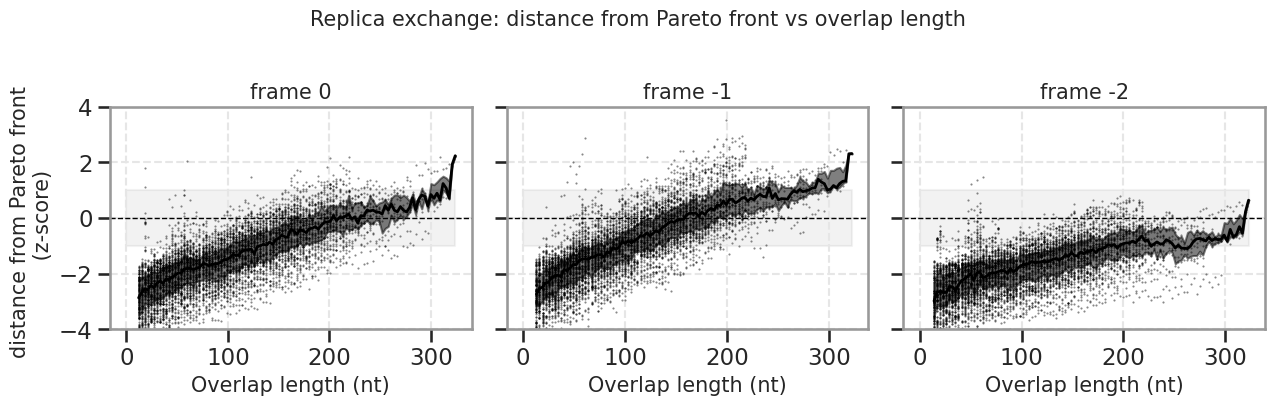

In [3]:
frame_labels = {0: "frame 0",
                1: "frame -1",
                2: "frame -2"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for frame, ax in zip([0, 1, 2], axes):
    sub = df[df["frame"] == frame]

    ax.axhline(0, color="k", lw=1, ls="--", zorder=1)

    ax.plot(
        sub["overlap_nuc"],
        sub["zscore_dist"],
        '.',
        color="k",
        alpha=0.5,
        zorder=1,
        markersize=1,
        )

    ax.set_xlabel("Overlap length (nt)")
    ax.set_title(frame_labels[frame])
    
    # Plot shaded region between -1 and 1
    ax.fill_between(
        x=[0, sub["overlap_nuc"].max()],
        y1=-1,
        y2=1,
        color="gray",
        alpha=0.1,
        zorder=0,
    )

    # median + IQR per overlap length
    grouped = sub.groupby("overlap_nuc")["zscore_dist"]
    med = grouped.median()
    q25 = grouped.quantile(0.25)
    q75 = grouped.quantile(0.75)

    ax.set_ylim(-4, 4)

    ax.plot(med.index, med.values, color="black", lw=2, zorder=3, label="median")
    ax.fill_between(med.index, q25.values, q75.values,
                    color="black", alpha=0.5, zorder=2, label="IQR")

axes[0].set_ylabel("distance from Pareto front \n (z-score)")

fig.suptitle("Replica exchange: distance from Pareto front vs overlap length",
             fontsize=15, y=1.02)
plt.tight_layout()
# plt.savefig("20260304_zscore_vs_overlap_by_frame.pdf", bbox_inches="tight", dpi=150)
plt.show()

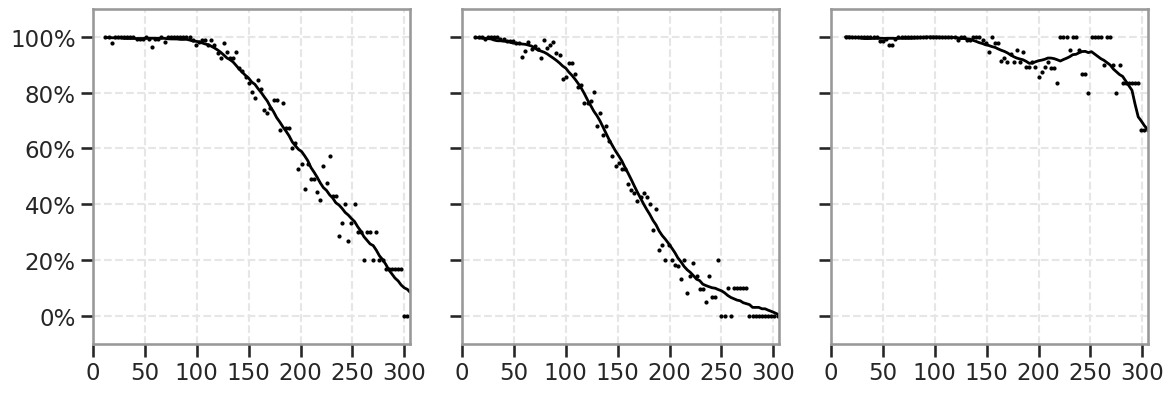

In [4]:
# Plot fraction of pairs with z-score < 0 by overlap length, split by frame
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for frame, ax in zip([0, 1, 2], axes):
    sub = df[df["frame"] == frame]

    # Calculate fraction of pairs with z-score < 0 for each overlap length
    grouped = sub.groupby("overlap_nuc")["zscore_dist"]
    fraction_better = (grouped.apply(lambda x: (x < 0).mean()))

    ax.plot(fraction_better.index, fraction_better.values, "ko", markersize=2)
    # # calculate a smoothed version using a rolling window
    smoothed = fraction_better.rolling(window=20, min_periods=1, center=True).mean()
    ax.plot(smoothed.index, smoothed.values, "-k", alpha=1, lw = 2)

    # put xticks every 50 nt
    ax.set_xticks(np.arange(0, sub["overlap_nuc"].max() + 1, 50))

    # Make y-ticks be percentages in steps of 20%
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.01, 0.2)])

    ax.set_ylim(-0.1, 1.1)
    ax.set_xlim(0,305)
    # ax.set_yscale("log")

plt.tight_layout()
# plt.savefig("20260327 Replica Panels/20260327_overlap_fractions.svg", bbox_inches="tight")

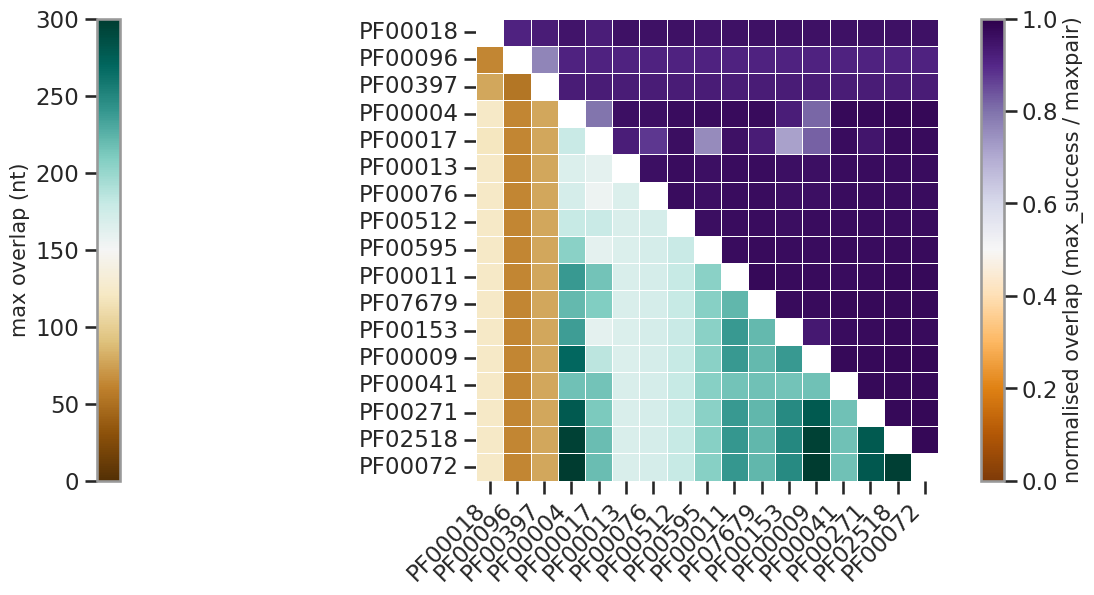

In [5]:
# Compute summary metric: max overlap (nt) still achieving z-score < 0, per (pf1, pf2) across all frames
# Lower triangle: absolute overlap (nt); Upper triangle: normalised to maxpair

max_success_all_frames = (
    df[df["zscore_dist"] < 0]
    .groupby(["pf1", "pf2"])["overlap_nuc"]
    .max()
    .reset_index()
    .rename(columns={"overlap_nuc": "max_success_overlap"})
)

# Compute maxpair = max overlap_nuc + 6 for each (pf1, pf2)
maxpair_df = (
    df.groupby(["pf1", "pf2"])["overlap_nuc"]
    .max()
    .reset_index()
    .rename(columns={"overlap_nuc": "max_overlap"})
)
maxpair_df["maxpair"] = maxpair_df["max_overlap"] + 6

# Merge and normalise
merged = max_success_all_frames.merge(maxpair_df[["pf1", "pf2", "maxpair"]], on=["pf1", "pf2"])
merged["norm_success"] = merged["max_success_overlap"] / merged["maxpair"]

all_pfams = sorted(pd.concat([df["pf1"], df["pf2"]]).unique())

pfam_score = (
    max_success_all_frames.groupby("pf1")["max_success_overlap"].mean()
    .add(max_success_all_frames.groupby("pf2")["max_success_overlap"].mean(), fill_value=0) / 2
)
pfam_order = pfam_score.reindex(all_pfams, fill_value=0).sort_values().index.tolist()

# Pivot tables
pivot_abs = max_success_all_frames.pivot(index="pf1", columns="pf2", values="max_success_overlap")
pivot_abs_sym = pivot_abs.combine_first(pivot_abs.T).reindex(index=pfam_order, columns=pfam_order)

pivot_norm = merged.pivot(index="pf1", columns="pf2", values="norm_success")
pivot_norm_sym = pivot_norm.combine_first(pivot_norm.T).reindex(index=pfam_order, columns=pfam_order)

# Masks
mask_upper = np.triu(np.ones_like(pivot_abs_sym, dtype=bool))   # hide upper tri for abs
mask_lower = np.tril(np.ones_like(pivot_norm_sym, dtype=bool))  # hide lower tri for norm

# Colormaps
cmap_lower = palettable.colorbrewer.diverging.BrBG_11.mpl_colormap
norm_lower = TwoSlopeNorm(vmin=0, vcenter=150, vmax=300)

cmap_upper = palettable.colorbrewer.diverging.PuOr_11.mpl_colormap
# cmap_upper = palettable.colorbrewer.diverging.Spectral_6.mpl_colormap

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

# Lower triangle: absolute overlap (nt)
sns.heatmap(
    pivot_abs_sym, ax=ax,
    cmap=cmap_lower, norm=norm_lower,
    linewidths=0.5, square=True,
    cbar=False,
    mask=mask_upper,
    xticklabels=True,
    yticklabels=True,
)

# Upper triangle: normalised overlap
sns.heatmap(
    pivot_norm_sym, ax=ax,
    cmap=cmap_upper, vmin=0, vmax=1,
    linewidths=0.5, square=True,
    cbar=False,
    mask=mask_lower,
    xticklabels=True,
    yticklabels=True,
)

ax.grid(False)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
ax.set_xticklabels(ax.get_xticklabels(), ha="right", rotation=45)
ax.tick_params(axis="y", rotation=0)

# Colorbars
fig.colorbar(ScalarMappable(norm=norm_lower, cmap=cmap_lower),
             ax=ax, label="max overlap (nt)", location="left", pad=0.12)
fig.colorbar(ScalarMappable(norm=plt.Normalize(0, 1), cmap=cmap_upper),
             ax=ax, label="normalised overlap (max_success / maxpair)", location="right")

# plt.savefig("20260327 Replica Panels/20260327_max_overlap_heatmap_all_frames_normalised.svg", bbox_inches="tight")
plt.show()

In [25]:
# Compute max overlap per frame for PF00041 and PF00072, divided by maxpair for that pair
pf1, pf2 = "PF00041", "PF00072"
sub = df[((df["pf1"] == pf1) & (df["pf2"] == pf2)) | ((df["pf1"] == pf2) & (df["pf2"] == pf1))]
maxpair = sub["overlap_nuc"].max() + 6
print(f"max attempted overlap for {pf1} and {pf2}: {maxpair - 6} nt")
print(f"Size of smaller gene for {pf1} x {pf2}: {maxpair} nt")
print("max overlap with z-score < 0 per frame:")
for frame in [0, 1, 2]:
    frame_sub = sub[sub["frame"] == frame]
    max_success = frame_sub[frame_sub["zscore_dist"] < 0]["overlap_nuc"].max()
    print(f"  frame {frame}: {max_success} nt ({max_success / maxpair:.2f} of maxpair)")


print()

pf1, pf2 = "PF00017", "PF00271"
sub = df[((df["pf1"] == pf1) & (df["pf2"] == pf2)) | ((df["pf1"] == pf2) & (df["pf2"] == pf1))]
maxpair = sub["overlap_nuc"].max() + 6
print(f"max attempted overlap for {pf1} and {pf2}: {maxpair - 6} nt")
print(f"Size of smaller gene for {pf1} x {pf2}: {maxpair} nt")
print("max overlap with z-score < 0 per frame:")
for frame in [0, 1, 2]:
    frame_sub = sub[sub["frame"] == frame]
    max_success = frame_sub[frame_sub["zscore_dist"] < 0]["overlap_nuc"].max()
    print(f"  frame {frame}: {max_success} nt ({max_success / maxpair:.2f} of maxpair)")

max attempted overlap for PF00041 and PF00072: 216 nt
Size of smaller gene for PF00041 x PF00072: 222 nt
max overlap with z-score < 0 per frame:
  frame 0: 216 nt (0.97 of maxpair)
  frame 1: 214 nt (0.96 of maxpair)
  frame 2: 215 nt (0.97 of maxpair)

max attempted overlap for PF00017 and PF00271: 219 nt
Size of smaller gene for PF00017 x PF00271: 225 nt
max overlap with z-score < 0 per frame:
  frame 0: 147 nt (0.65 of maxpair)
  frame 1: 94 nt (0.42 of maxpair)
  frame 2: 212 nt (0.94 of maxpair)


17 Pfams; 408 (pair, frame) combinations with ≥1 successful overlap


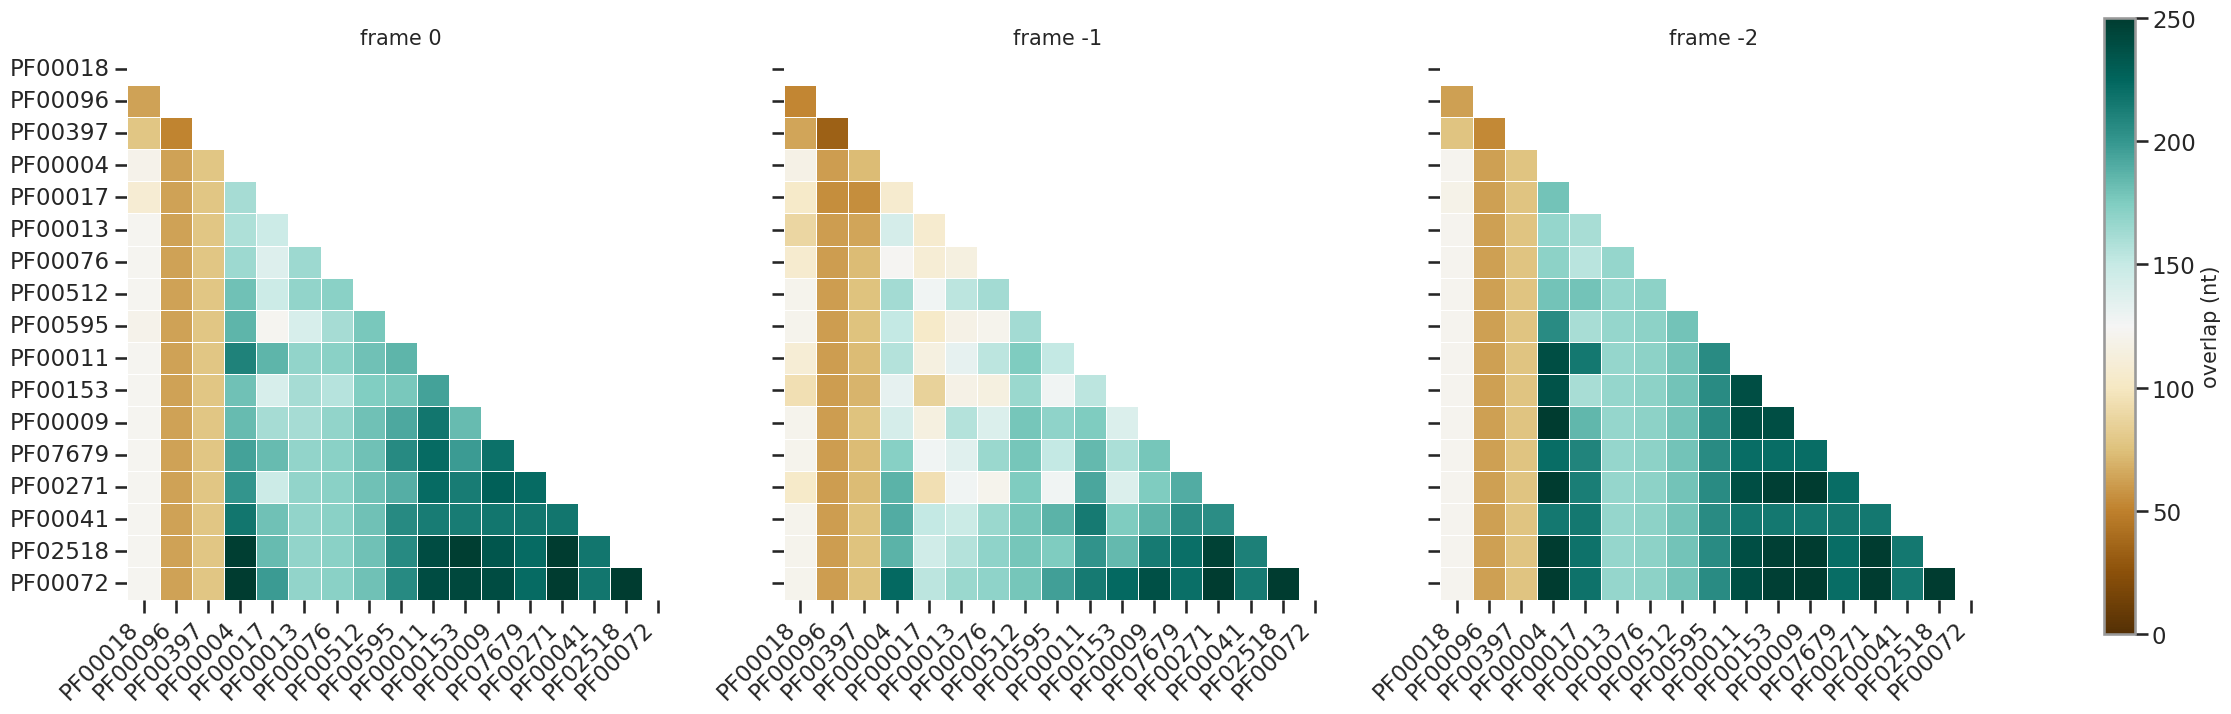

In [7]:


# ── Compute summary metric: max overlap (nt) still achieving z-score < 0, per (pf1, pf2, frame) ──
max_success = (
    df[df["zscore_dist"] < 0]
    .groupby(["pf1", "pf2", "frame"])["overlap_nuc"]
    .max()
    .reset_index()
    .rename(columns={"overlap_nuc": "max_success_overlap"})
)

all_pfams = sorted(pd.concat([df["pf1"], df["pf2"]]).unique())
print(f"{len(all_pfams)} Pfams; {len(max_success)} (pair, frame) combinations with ≥1 successful overlap")

# ── Pairwise heatmaps, one panel per frame ──────────────────────────────────────────────────────
pfam_score = (
    max_success.groupby("pf1")["max_success_overlap"].mean()
    .add(max_success.groupby("pf2")["max_success_overlap"].mean(), fill_value=0) / 2
)
pfam_order = pfam_score.reindex(all_pfams, fill_value=0).sort_values().index.tolist()

vmax = max_success["max_success_overlap"].max()

cmap = palettable.colorbrewer.diverging.BrBG_11.mpl_colormap
norm = TwoSlopeNorm(vmin=0, vcenter=125, vmax=250)

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

for frame, ax in zip([0, 1, 2], axes):
    sub = max_success[max_success["frame"] == frame]
    pivot = sub.pivot(index="pf1", columns="pf2", values="max_success_overlap")
    pivot_sym = pivot.combine_first(pivot.T).reindex(index=pfam_order, columns=pfam_order)

    mask = np.triu(np.ones_like(pivot_sym, dtype=bool))  # hide upper triangle + diagonal

    sns.heatmap(
        pivot_sym, ax=ax,
        cmap=cmap, norm=norm,
        linewidths=0.5, square=True,
        cbar=False,
        mask=mask,
        xticklabels=True,
        yticklabels=True,
    )
    ax.grid(False)
    ax.set_title(frame_labels[frame])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
             ax=axes, label="overlap (nt)")

# fig.suptitle("Max overlap length still achieving z-score < 0, by Pfam pair", y=1.01)
# plt.tight_layout()
# plt.savefig("20260327 Replica Panels/20260327_max_overlap_heatmap.svg", bbox_inches="tight")
plt.show()

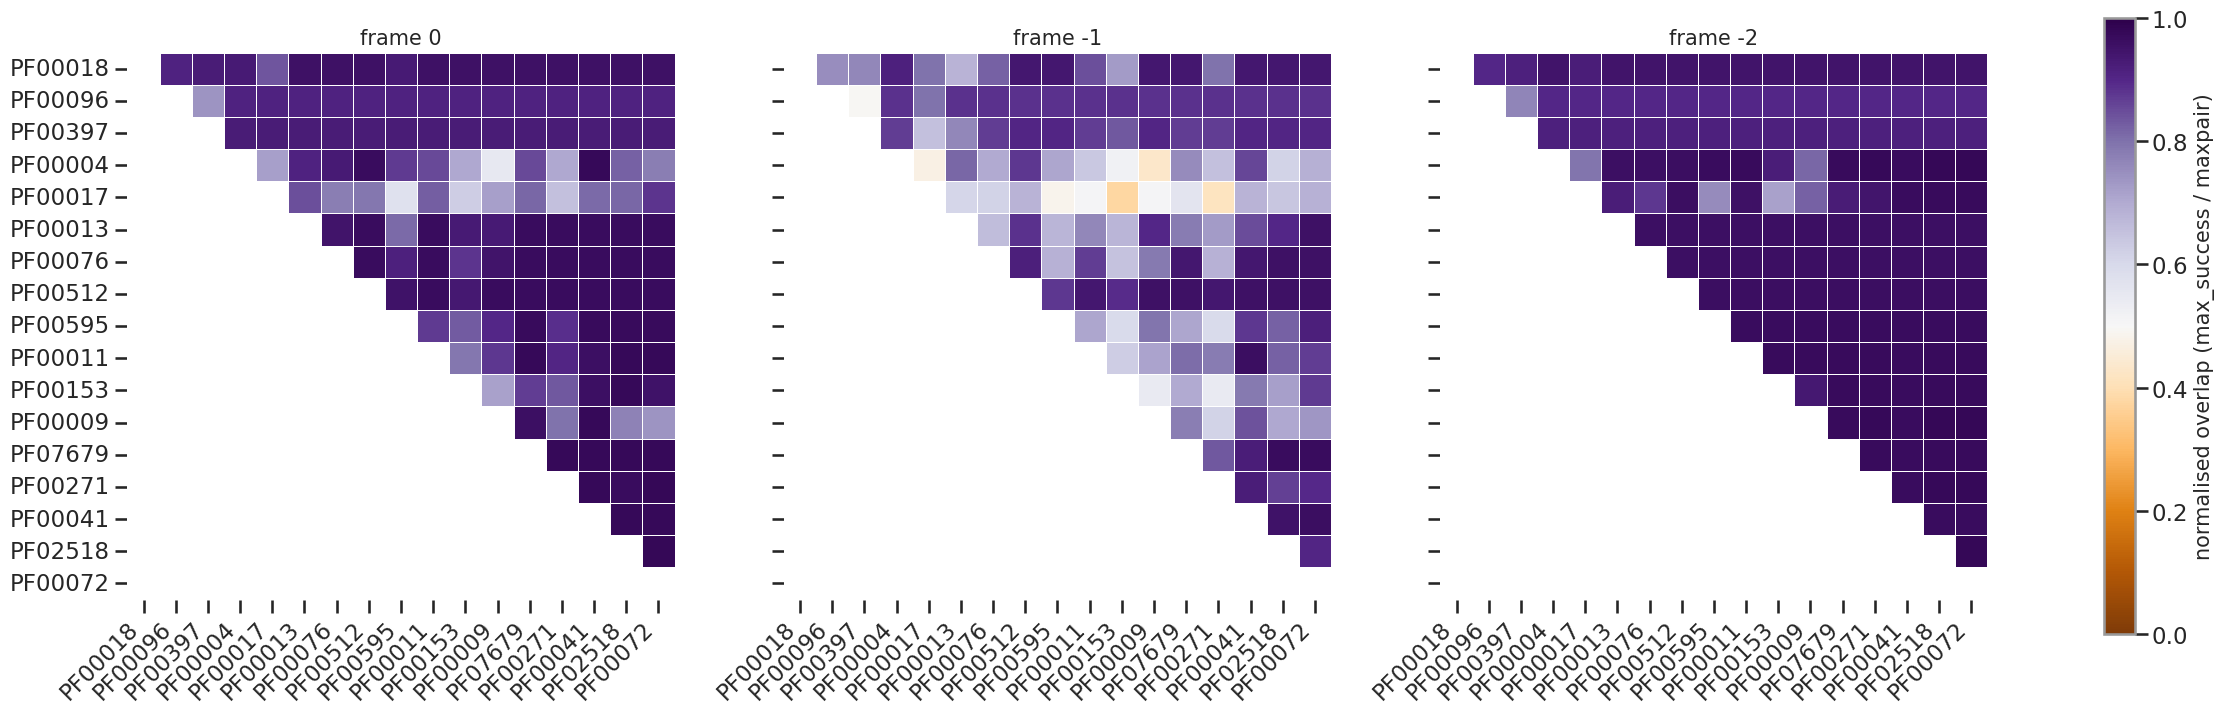

In [8]:
# Normalised overlap heatmap split by frame
max_success_per_frame = (
    df[df["zscore_dist"] < 0]
    .groupby(["pf1", "pf2", "frame"])["overlap_nuc"]
    .max()
    .reset_index()
    .rename(columns={"overlap_nuc": "max_success_overlap"})
)

maxpair_df = (
    df.groupby(["pf1", "pf2"])["overlap_nuc"]
    .max()
    .reset_index()
    .rename(columns={"overlap_nuc": "max_overlap"})
)
maxpair_df["maxpair"] = maxpair_df["max_overlap"] + 6

merged = max_success_per_frame.merge(maxpair_df[["pf1", "pf2", "maxpair"]], on=["pf1", "pf2"])
merged["norm_success"] = merged["max_success_overlap"] / merged["maxpair"]

all_pfams = sorted(pd.concat([df["pf1"], df["pf2"]]).unique())
pfam_score = (
    max_success_per_frame.groupby("pf1")["max_success_overlap"].mean()
    .add(max_success_per_frame.groupby("pf2")["max_success_overlap"].mean(), fill_value=0) / 2
)
pfam_order = pfam_score.reindex(all_pfams, fill_value=0).sort_values().index.tolist()

cmap_upper = palettable.colorbrewer.diverging.PuOr_11.mpl_colormap
mask_lower = np.tril(np.ones((len(pfam_order), len(pfam_order)), dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharey=True)

for frame, ax in zip([0, 1, 2], axes):
    sub = merged[merged["frame"] == frame]
    pivot = sub.pivot(index="pf1", columns="pf2", values="norm_success")
    pivot_sym = pivot.combine_first(pivot.T).reindex(index=pfam_order, columns=pfam_order)

    sns.heatmap(
        pivot_sym, ax=ax,
        cmap=cmap_upper, vmin=0, vmax=1,
        linewidths=0.5, square=True,
        cbar=False,
        mask=mask_lower,
        xticklabels=True,
        yticklabels=True,
    )
    ax.grid(False)
    ax.set_title(frame_labels[frame])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right", rotation=45)
    ax.tick_params(axis="y", rotation=0)

fig.colorbar(ScalarMappable(norm=plt.Normalize(0, 1), cmap=cmap_upper),
             ax=axes, label="normalised overlap (max_success / maxpair)")

# plt.savefig("20260327 Replica Panels/20260327_norm_overlap_heatmap_by_frame.svg", bbox_inches="tight")
# plt.tight_layout()
